In [32]:
# IMPORTS
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [31]:
# load saved models after training ( so i don't have to run all cells again )
rf_model = joblib.load("../models/rf_model.joblib")
lr_model = joblib.load("../models/logreg_model.joblib")

In [3]:
# raw data
cdcd_data = pd.read_csv("../data/cdcd.csv")
cdcd_data['gender'] = cdcd_data['gender'].map({'Male': 0, 'Female': 1})
cdcd_data = cdcd_data.dropna(subset=['gender']) # drop any where there is no gender value

# only get the columns that will be used: gender, age, bmi, glucose, hypertension, hba1c level, outcome
cdcd_data = cdcd_data[['gender','age','bmi','blood_glucose_level', 'hypertension', 'hbA1c_level', 'diabetes']]
print(cdcd_data['gender'].unique())
cdcd_data.describe()

[1. 0.]


,gender,age,bmi,blood_glucose_level,hypertension,hbA1c_level,diabetes
count,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000
mean,0.585625,41.888076,27.320757,138.057810,0.074863,5.527529,0.085015
std,0.492616,22.517206,6.636853,40.709469,0.263172,1.070665,0.278906
min,0.000000,0.080000,10.010000,80.000000,0.000000,3.500000,0.000000
25%,0.000000,24.000000,23.630000,100.000000,0.000000,4.800000,0.000000
50%,1.000000,43.000000,27.320000,140.000000,0.000000,5.800000,0.000000
75%,1.000000,60.000000,29.580000,159.000000,0.000000,6.200000,0.000000
max,1.000000,80.000000,95.690000,300.000000,1.000000,9.000000,1.000000


In [4]:
cdcd_data = cdcd_data.drop_duplicates()
print("Duplicates: (cdcd)", cdcd_data.duplicated().sum()) 

print(cdcd_data.isnull().sum())       # counts of missing values
print((cdcd_data == 0).sum())         # counts of zeros


Duplicates: (cdcd) 0
gender                 0
age                    0
bmi                    0
blood_glucose_level    0
hypertension           0
hbA1c_level            0
diabetes               0
dtype: int64
gender                 37873
age                        0
bmi                        0
blood_glucose_level        0
hypertension           83557
hbA1c_level                0
diabetes               82523
dtype: int64


In [5]:
# clean data
# limit cdcd data
cdcd_data = cdcd_data[cdcd_data['age'] >= 18] # adults only
cdcd_data = cdcd_data[(cdcd_data['bmi'] >= 15) & (cdcd_data['bmi'] <= 60)] # bmi should be 15-60
cdcd_data = cdcd_data[(cdcd_data['blood_glucose_level'] >= 50) & (cdcd_data['blood_glucose_level'] <= 250)] # glucose level should be 50-250 

# resample
majority = cdcd_data[cdcd_data['diabetes'] == 0]  # more with no diabetes
minority = cdcd_data[cdcd_data['diabetes'] == 1]
majority_downsample = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)
cdcd_data = pd.concat([majority_downsample, minority])
print(cdcd_data.describe())
cdcd_data.to_csv("../data/cdcd_clean.csv", index=False)



             gender           age           bmi  blood_glucose_level  \
count  12614.000000  12614.000000  12614.000000         12614.000000   
mean       0.571825     54.318059     30.112641           149.813144   
std        0.494834     17.387356      6.882928            39.246620   
min        0.000000     18.000000     15.040000            80.000000   
25%        0.000000     42.000000     26.290000           130.000000   
50%        1.000000     56.000000     27.725000           145.000000   
75%        1.000000     68.000000     33.470000           160.000000   
max        1.000000     80.000000     59.990000           240.000000   

       hypertension   hbA1c_level     diabetes  
count  12614.000000  12614.000000  12614.00000  
mean       0.164341      6.156128      0.50000  
std        0.370600      1.290898      0.50002  
min        0.000000      3.500000      0.00000  
25%        0.000000      5.700000      0.00000  
50%        0.000000      6.100000      0.50000  
75%     

In [17]:
# data
features = ['gender','age','bmi','blood_glucose_level','hypertension','hbA1c_level']
X = cdcd_data[features] # features
y = cdcd_data["diabetes"] # target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


print("X_train Shape:",  X_train.shape)
print("X_test Shape:", X_test.shape)
print("Y_train Shape:", y_train.shape)
print("Y_test Shape:", y_test.shape)

X_train Shape: (8829, 6)
X_test Shape: (3785, 6)
Y_train Shape: (8829,)
Y_test Shape: (3785,)


In [7]:
# train logistic regression
log_reg = LogisticRegression(max_iter=1000, C=0.01, class_weight='balanced')
log_reg.fit(X_train, y_train)

lr_scores = cross_val_score(log_reg, X, y, cv=5, scoring='accuracy')
print(lr_scores)
print(lr_scores.mean())
# test logistic regression
y_pred_lr = log_reg.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)

[0.8489893  0.85453825 0.8489893  0.86246532 0.87430611]
0.8578576540710475


In [ ]:
# train random forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               
    scoring='f1', # metric to optimize
    n_jobs=-1 # use all CPU cores
)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_)

In [34]:
rf.fit(X_train, y_train)
rf_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(rf_scores)
print(rf_scores.mean())

# test random forest
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
 

# test gridsearch
rf_model.set_params(class_weight='balanced')
y_pred_best_rf = rf_model.predict(X_test)
best_rf_acc = accuracy_score(y_test, y_pred_best_rf)


[0.87871581 0.87911217 0.86167261 0.87911217 0.88818398]
0.8773593487103423


In [ ]:
# save models
joblib.dump(log_reg, '../models/logreg_model.joblib')
joblib.dump(best_rf, '../models/rf_model.joblib')

['../models/rf_model.joblib']

vvv evaluate and interpret predictions vvv

In [37]:
# evaluation
# confusion matrix: tn, fp, fn, tp
print("logistic regression accuracy:", lr_acc)
# accuracy: 0.912
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

print("random forest accuracy", rf_acc)
# accuracy: 0.901
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)
print("random forest accuracy (gridsearch best estimator):", best_rf_acc)
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
print(cm_best_rf)


logistic regression accuracy: 0.8589167767503303
[[1642  289]
 [ 245 1609]]
random forest accuracy 0.8739762219286658
[[1673  258]
 [ 219 1635]]
random forest accuracy (gridsearch best estimator): 0.8856010568031704
[[1655  276]
 [ 157 1697]]


In [ ]:
# interpret logistic regression

# coefficients
coefficients = log_reg.coef_[0]  # array of feature coefficients (1 unit inc in feature -> change in log odds)
# +: increase risk, -: decrease risk
features = X_train.columns
for f, c in zip(features, coefficients):
    print(f"{f}: {c:.3f}")
print("-------------------")
# odds ratios
odds_ratios = np.exp(coefficients) # get exponentials
for f, oratio in zip(features, odds_ratios):
    print(f"{f}: {oratio:.2f}")

gender: -0.190
age: 0.050
bmi: 0.095
blood_glucose_level: 0.027
hypertension: 0.395
hbA1c_level: 1.632
-------------------
gender: 0.83
age: 1.05
bmi: 1.10
blood_glucose_level: 1.03
hypertension: 1.48
hbA1c_level: 5.11


In [ ]:
# interpret random forest
importances = rf_model.feature_importances_
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.3f}")

gender: 0.004
age: 0.156
bmi: 0.073
blood_glucose_level: 0.244
hypertension: 0.025
hbA1c_level: 0.498


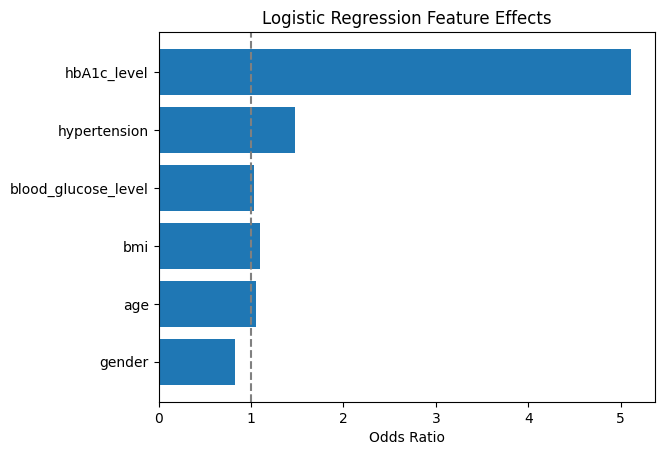

In [24]:
# plot odds ratios
odds_ratios = [0.83,1.05,1.10,1.03,1.48,5.11]

plt.barh(features, odds_ratios)
plt.xlabel("Odds Ratio")
plt.title("Logistic Regression Feature Effects")
plt.axvline(x=1, color='grey', linestyle='--')  # line at OR=1
plt.savefig("../figures/lr_feature_effects.png", bbox_inches="tight")
plt.show()

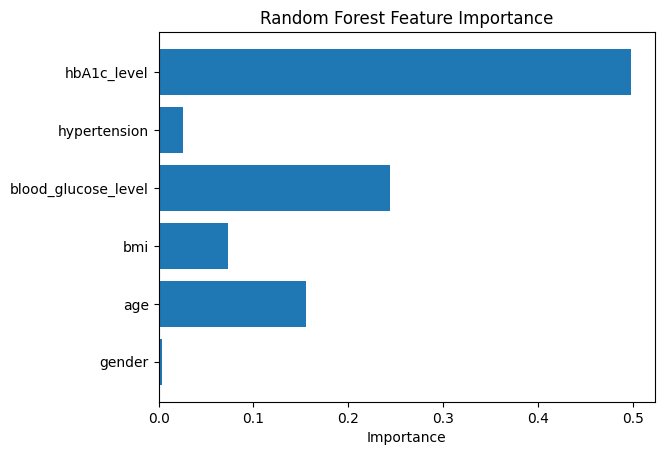

In [28]:
# plot feature importance (rf)
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.savefig("../figures/rf_feature_importance.png", bbox_inches="tight")
plt.show()

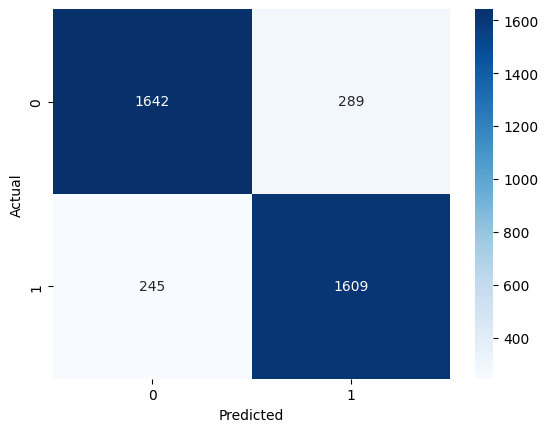

In [41]:
# cm for logreg
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../figures/lr_cm.png", bbox_inches="tight")
plt.show()

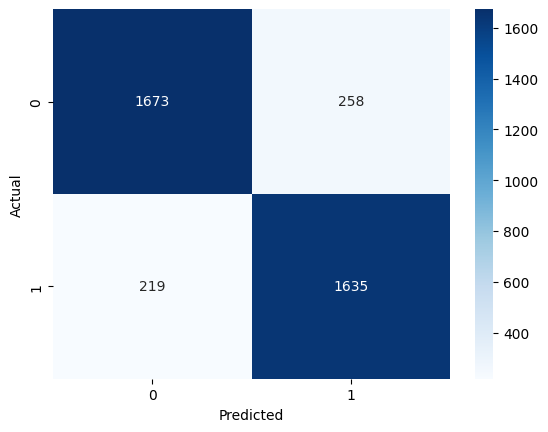

In [44]:
# cm for rf original model
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../figures/rf_cm.png", bbox_inches="tight")
plt.show()

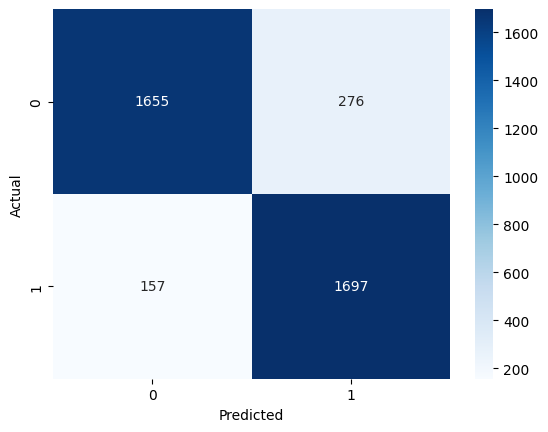

In [43]:
# cm for rf gridsearch
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../figures/best_rf_cm.png", bbox_inches="tight")
plt.show()